In [1]:
# 必要なライブラリの読み込み
import numpy as np
from scipy import stats
from scipy.stats import poisson

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<大数の法則>
大数の法則は「標本の大きさが大きくなるにつれて標本平均が母平均に近づく」というものです。ここでは平均4、標準偏差0.8の正規分布から10個、110個、…、100100個とサンプリングを繰り返し、それぞれのサンプルの平均値がどのように変化するかを確認してみましょう。

In [7]:
# 平均4、標準偏差0.8の正規分布を母集団(population)とします
population = stats.norm(loc=4, scale=0.8)
#説明：　変数 populationにこの分布を格納（フリーズ）することで、以降のコードでパラメータを毎回指定せずに様々な統計量を算出できます。
#例えば、population.rvs(size=100) で、この分布に従う100個のデータ（乱数）をランダムに抽出できます。

# サンプルサイズを指定（10から100100まで100刻み）
sample_size = np.arange(start=10, stop=100100, step = 100)

#print(sample_size)

# 計算結果を格納する変数を作成
sample_mean = []

# 再現性を確保するためにseedを設定
np.random.seed(1)
for i in sample_size:
    #sample_size分だけpopulationからサンプリング
    sample = population.rvs(size = i)
    sample_mean.append(np.mean(sample))

Text(0, 0.5, 'Sample mean')

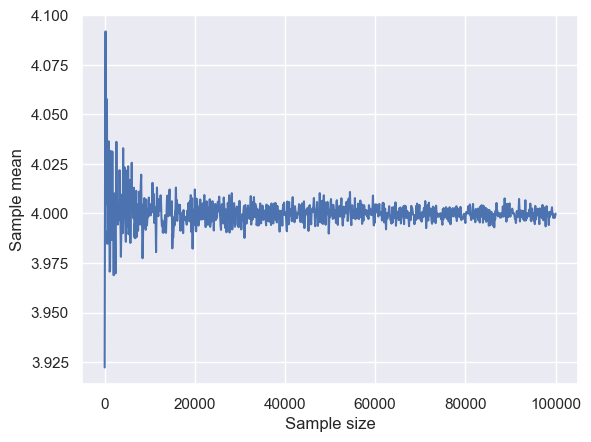

In [8]:
# 結果を表示
plt.plot(sample_size, sample_mean)
plt.xlabel('Sample size')
plt.ylabel('Sample mean')

サンプルサイズが増えるに従い、サンプルの平均値が4に近づいていることがわかります。これで大数の法則が意味するところを確認できました。

<中心極限定理>
中心極限定理 とは「母集団の分布が何であれ、サンプルサイズが大きい場合には確率変数の和は正規分布に近いものとなる」というものです。

コインを投げるという事象はベルヌーイ試行であり、これを繰り返すと二項分布に従うということは、前のレッスンで学習しました。この事象を例にとって、コインを10000回投げた場合に表が出た回数を数える、という試行を50000回繰り返してみましょう。この法則によるならば、結果は正規分布に近いものとなるはずです。

補足：
item = np.random.choice(配列, size=抽出数, replace=True/False, p=確率リスト)は、配列から1つ選んでitemに格納するという意味。

In [9]:
n_size = 10000          #コインを投げる回数
n_trial = 50000         #試行回数
coin = np.array([0,1])  #コインの表裏を0,1とする

np.random.seed(1)       #再現性を確保するためにseedを設定

result = []
for i in range(n_trial):  #n_trial回以下の処理を繰り返す
    #coinからn_size回ランダムサンプリングを実施
    result_each_trial = np.random.choice(coin, size = n_size, replace=True)
    count_head = sum(result_each_trial)
    result.append(count_head)

resultにそれぞれの試行の結果が格納されました。この分布を確認してみましょう。

In [13]:
#result

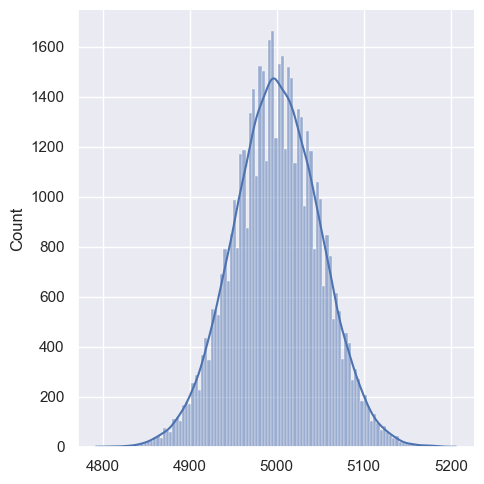

In [14]:
# 結果を表示
sns.displot(result, kde=True)

左右対称のヒストグラムになっており、正規分布にとても近いものとなったことがわかります。これが中心極限定理の意味するところです。

<二項分布とポアソン分布>
二項分布の期待値はnを試行回数、pを成功確率とした場合npで与えられることがわかっています。こちらについてもシミュレーションで確認してみましょう。

成功確率 p=0.00000003 となる事象を n=100000000 回繰り返したとします。この試行を10000回行った場合に成功する回数を数えてみましょう。

補足：np.random.binomial は、NumPy ライブラリで二項分布（Binomial Distribution）に従う乱数を生成するための関数です。 
「成功確率pの試行をn回行ったとき、何回成功するか」というシミュレーション結果を返します。

In [15]:
# n=100000000、p=0.00000003の二項分布に従う乱数を10000個生成
n=100000000
p=0.00000003

np.random.seed(1)
result = np.random.binomial(n=n, p=p, size=10000)

成功回数の分布は下記の通りです。

(array([1992., 2233., 2273., 1711.,  986.,  471.,  219.,   80.,   30.,
           5.]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <BarContainer object of 10 artists>)

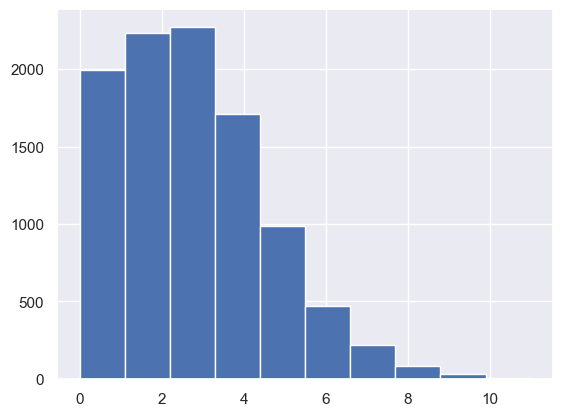

In [16]:
# 結果を表示
plt.hist(result)

さて、この平均は何回になるでしょうか。n * p = 3.0 ですので、その付近になるはずです。

In [17]:
# 平均を表示
print(sum(result)/len(result))

2.9876


予想通り、3に近くなりました。

このようにpの値が非常に小さく、nの値が大きい二項分布は、λ＝np のポアソン分布に従うことが知られています。

次に、この事象が λ＝3 のポアソン分布に従うことを確認してみましょう。λ=3のポアソン分布の確率質量関数を確認します。

なお、今回は学習のためポアソン分布の計算に、NumPyとSciPyのそれぞれのメソッド（np.random.poisson、stats.poisson）を用います。確率質量関数は、SciPyのpmfメソッドを用いて計算します。

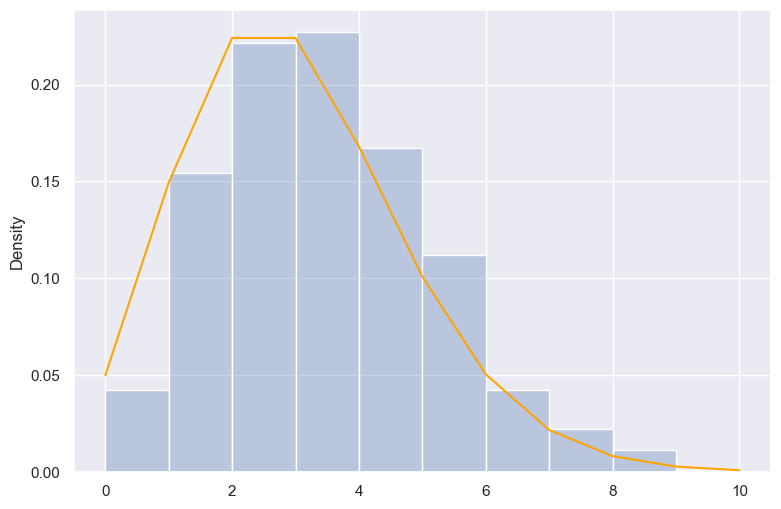

In [18]:
# NumPy
np.random.seed(1)
rvs_poisson = np.random.poisson(lam=3, size=1000)  #ポアソン分布に従う乱数を1,000個生成するコード

# SciPy
m = list(range(0,11))  #計算対象となるイベント発生回数のリスト [0, 1, 2, ..., 10] を作成
poisson = stats.poisson(mu=3)  #平均発生回数3のポアソン分布モデルを定義（フリーズ）
pmf_poisson = poisson.pmf(k=m)  #各m（0回〜10回）に対して、その回数が発生する理論上の確率を計算し、配列で返し

# 結果を描画
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(rvs_poisson, bins=m, kde=False, stat="density", alpha=0.3, ax=ax)
ax.plot(m, pmf_poisson, color="orange")

これはとても二項分布に近くなったのではないでしょうか。念のため、n=100000000、p=0.00000003 の二項分布の確率質量関数を確認してみましょう。

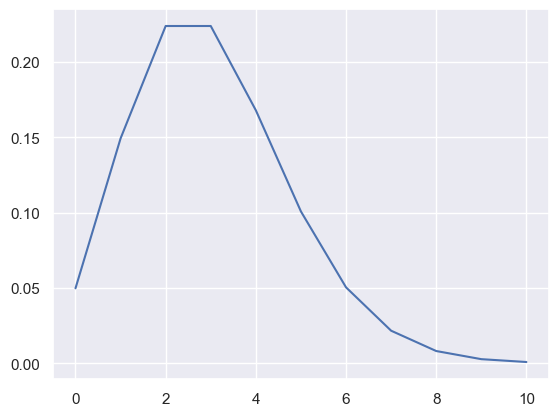

In [10]:
# 二項分布の確率質量関数を表示
np.random.seed(1)
binomial = stats.binom(n=n, p=p)
pmf_binomial = binomial.pmf(m)
plt.plot(m, pmf_binomial)